## 第四章 模型选择和评估

In [1]:
## 输出高清图像
%config InlineBackend.figure_format = 'retina'
%matplotlib inline
## 图像显示中文的问题
import matplotlib
matplotlib.rcParams['axes.unicode_minus']=False

import seaborn as sns  ## 设置绘图的主题
sns.set(font= "Kaiti",style="ticks",font_scale=1.4)

import pandas as pd  # 设置数据表每个单元显示内容的最大宽度
pd.set_option("max_colwidth", 100) 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.model_selection import KFold,StratifiedKFold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mlxtend.plotting import plot_decision_regions
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

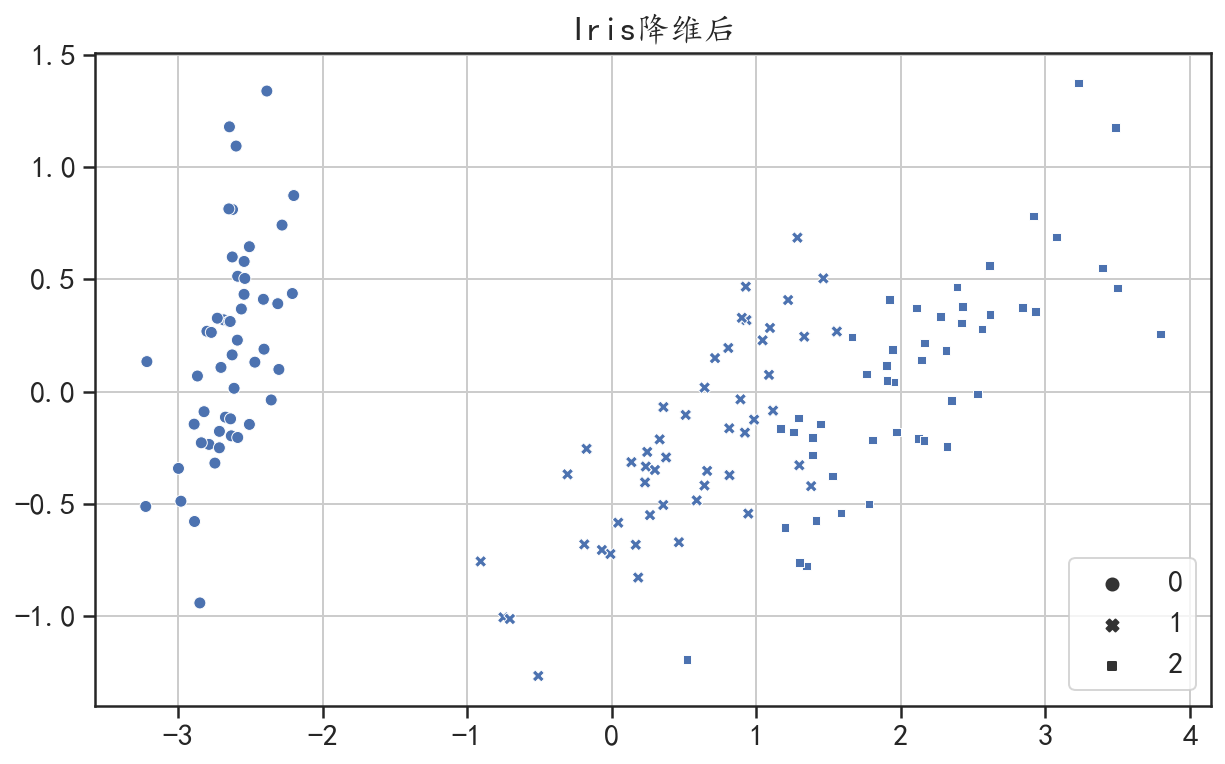

In [3]:
## 数据准备,读取鸢尾花数据集
X,y = load_iris(return_X_y=True)
## 为了方便数据的可视化分析，将数据降维到二维空间中
pca = PCA(n_components=2,random_state=3)
X = pca.fit_transform(X)
## 可视化数据降维后在空间中的分布情况
plt.figure(figsize = (10,6))
sns.scatterplot(x = X[:,0],y =  X[:,1],style = y)
plt.title("Iris降维后")
plt.legend(loc="lower right")
plt.grid()
plt.show()

### 4.2 模型训练

#### 4.2.1 交叉验证

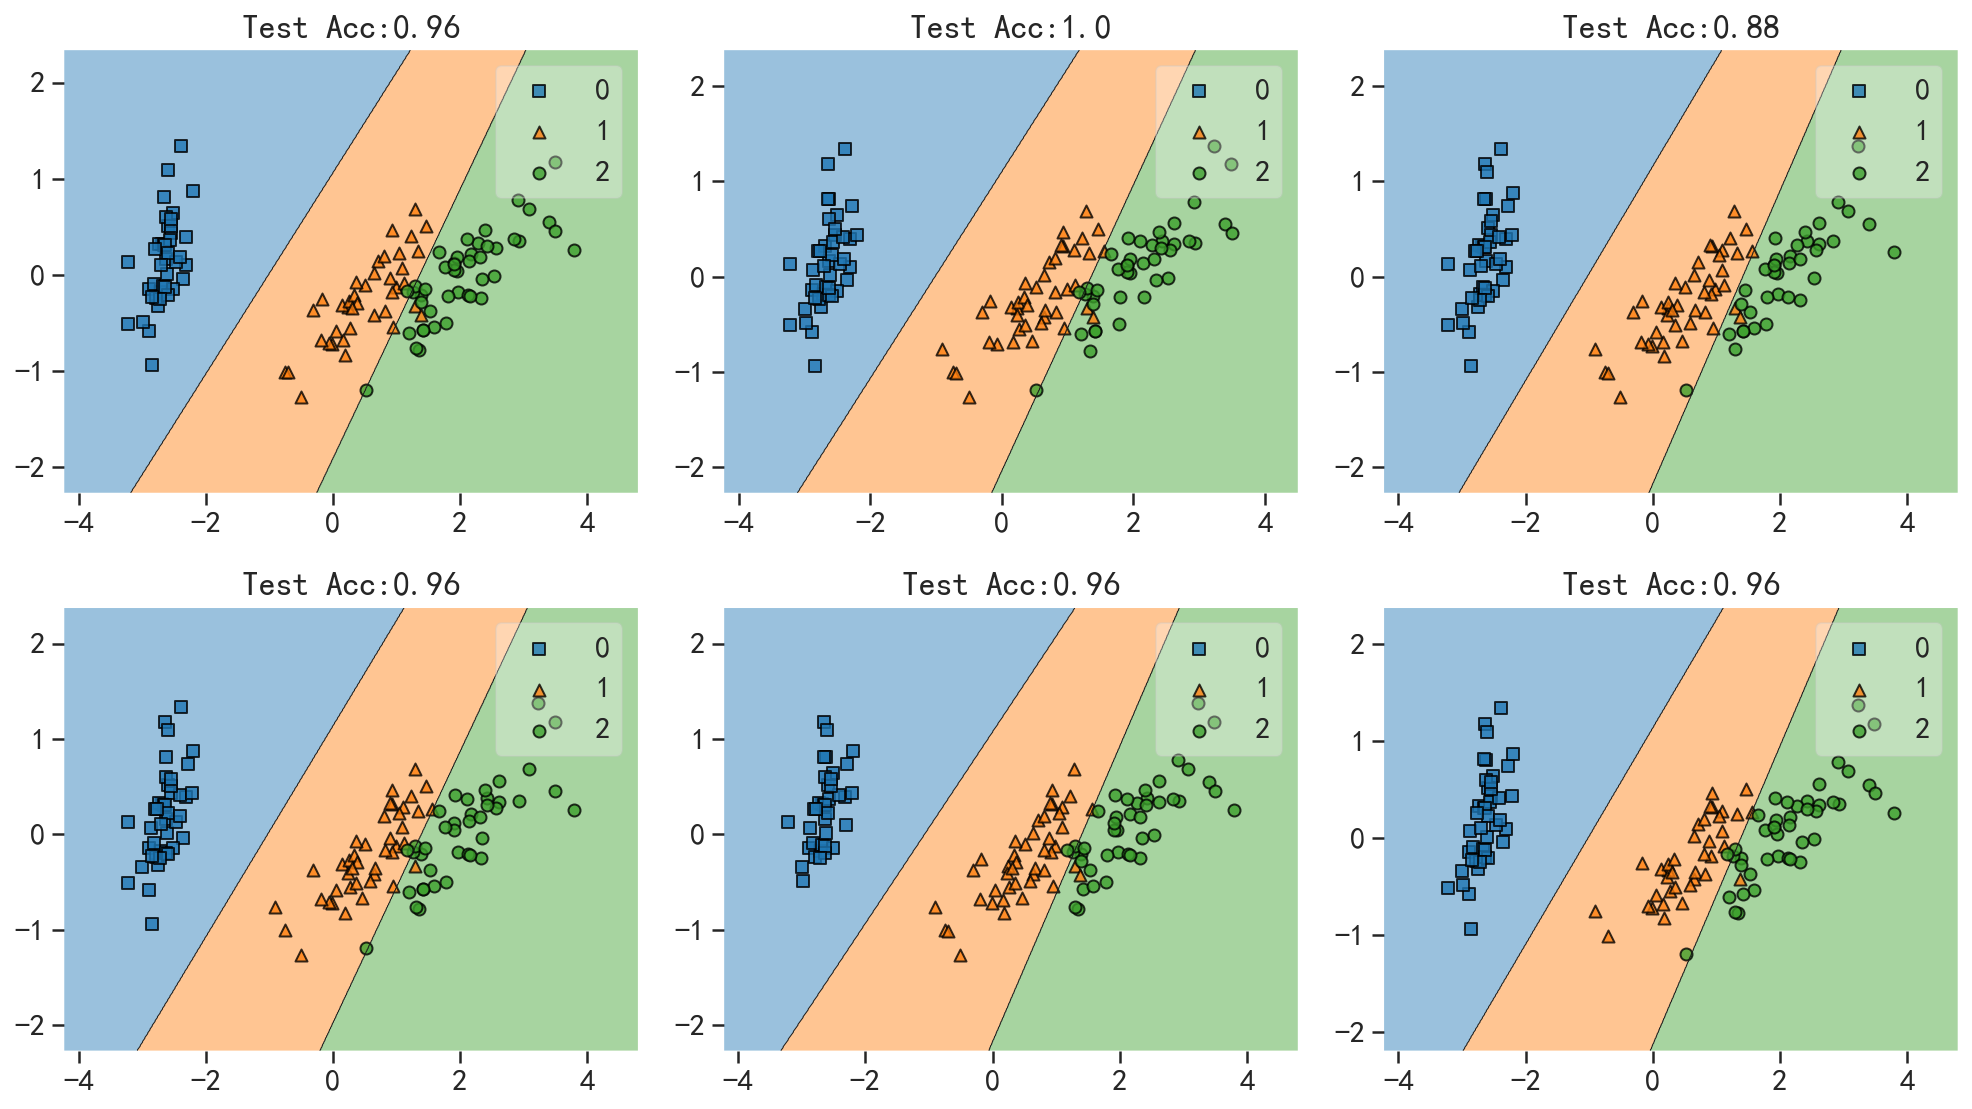

平均Acc: 0.9533333333333333


In [4]:
## K折交叉验证（KFold）

## 使用KFold对Iris数据集分类
kf = KFold(n_splits=6,random_state=1,shuffle=True)
datakf = kf.split(X,y)      ## 获取6折数据
## 使用线性判别分类算法进行数据分类
LDA_clf = LinearDiscriminantAnalysis(n_components=2)
scores = []              ## 用于保存每个测试集上的精度
plt.figure(figsize=(14,8))
for ii, (train_index, test_index) in enumerate(datakf):
    ## 使用每个部分的训练数据训练模型
    LDA_clf = LDA_clf.fit(X[train_index],y[train_index])
    ## 计算每次在测试数据上的预测精度
    prey = LDA_clf.predict(X[test_index])
    acc = metrics.accuracy_score(y[test_index],prey)
    ## 可视化每个模型在训练数据上的切分平面
    plt.subplot(2,3,ii+1)
    plot_decision_regions(X[train_index],y[train_index],LDA_clf)
    plt.title("Test Acc:"+str(np.round(acc,4)))
    scores.append(acc)
plt.tight_layout()
plt.show()
## 计算准确率的平均值
print("平均Acc:",np.mean(scores))

In [5]:
## 同时sklearn还提供了cross_val_score函数直接计算平均得分
scores = cross_val_score(estimator=LDA_clf,cv=6,X=X,y = y,n_jobs = 4)
print("6折交叉验证的Acc:\n",scores)
print("平均Acc:",np.mean(scores))

## 这里在每个测试集上获得的精度和前面的不一样，这是因为每个flod的数据有差异

6折交叉验证的Acc:
 [0.96 1.   0.96 0.92 0.96 1.  ]
平均Acc: 0.9666666666666667


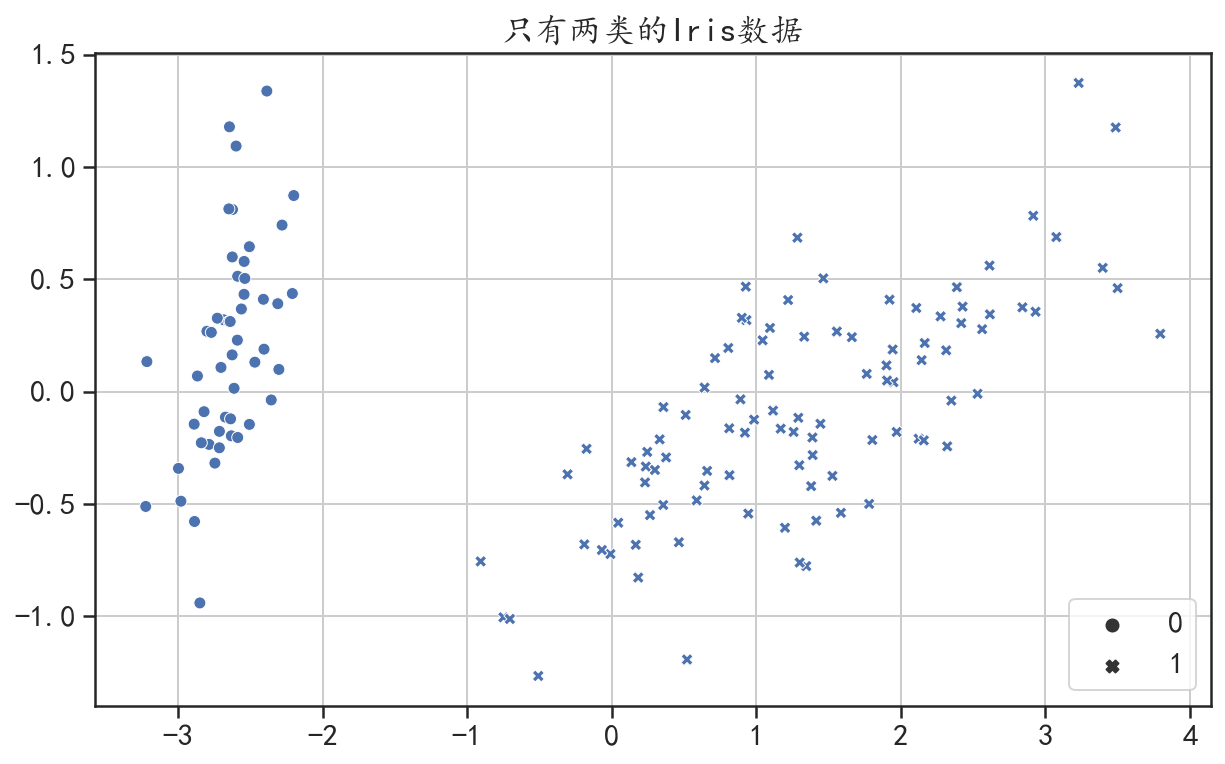

In [6]:
## Stratified k-fold 分层交叉验证

## StratifiedKFold()这个函数较常用，比KFold的优势在于将k折数据按照百分比划分数据集，
## 保证每个类别百分比在训练集和测试集中都是一样，这样能保证不会有某个类别的数据在训练集中而测试集中没有这种情况，
## 同样不会在训练集中没有全在测试集中，这样会导致结果糟糕透顶。


## 将数据中的第1和第2类归位同一类
ynew = np.where(y == 0, 0,1)

plt.figure(figsize = (10,6))
sns.scatterplot(x = X[:,0],y =  X[:,1],style = ynew)
plt.title("只有两类的Iris数据")
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [7]:
## KFold交叉验证
kf = KFold(n_splits=5,random_state=1,shuffle=True)
datakf = kf.split(X,ynew)      
for ii,(train_index, test_index) in enumerate(datakf):
    print("每个测试集的类别比例:\n",np.unique(ynew[test_index],return_counts = True))

## 并不是每个组的测试集上两类数据比例是1:2

每个测试集的类别比例:
 (array([0, 1]), array([11, 19]))
每个测试集的类别比例:
 (array([0, 1]), array([ 8, 22]))
每个测试集的类别比例:
 (array([0, 1]), array([11, 19]))
每个测试集的类别比例:
 (array([0, 1]), array([10, 20]))
每个测试集的类别比例:
 (array([0, 1]), array([10, 20]))


In [8]:
Skf = StratifiedKFold(n_splits=5,random_state=2,shuffle=True)
Skfdata = Skf.split(X,ynew)
for ii,(train_index, test_index) in enumerate(Skfdata):
    print("每个测试集的类别比例:\n",np.unique(ynew[test_index],return_counts = True))

## 每个组的测试集上两类数据比例均为1:2

每个测试集的类别比例:
 (array([0, 1]), array([10, 20]))
每个测试集的类别比例:
 (array([0, 1]), array([10, 20]))
每个测试集的类别比例:
 (array([0, 1]), array([10, 20]))
每个测试集的类别比例:
 (array([0, 1]), array([10, 20]))
每个测试集的类别比例:
 (array([0, 1]), array([10, 20]))


#### 4.2.2 参数搜索

In [9]:
## 切分数据集为训练集和测试集
train_x,test_x,train_y,test_y = train_test_split(
    X,y,test_size = 0.25,random_state = 2)
## 定义模型流程
pipe_KNN = Pipeline([("scale",StandardScaler()), # 数据标准化操作
                     ("pca",PCA()),              # 主成分降维操作
                     ("KNN",KNeighborsClassifier())])# KNN分类操作
## 定义需要搜索的参数
n_neighbors = np.arange(1,10)
para_grid = [{"scale__with_mean":[True,False], # 数据标准化搜索的参数
              "pca__n_components":[2,3],       # 主成分降维操作搜索的参数
              "KNN__n_neighbors" : n_neighbors}] # KNN分类操作搜索的参数

## 应用到数据上,使用5折交叉验证
gs_KNN_ir = GridSearchCV(estimator=pipe_KNN,param_grid=para_grid,
                         cv=5,n_jobs=4)
gs_KNN_ir.fit(train_x,train_y)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scale', StandardScaler()),
                                       ('pca', PCA()),
                                       ('KNN', KNeighborsClassifier())]),
             n_jobs=4,
             param_grid=[{'KNN__n_neighbors': array([1, 2, 3, 4, 5, 6, 7, 8, 9]),
                          'pca__n_components': [2, 3],
                          'scale__with_mean': [True, False]}])

In [10]:
## 输出最优的参数
gs_KNN_ir.best_params_

{'KNN__n_neighbors': 5, 'pca__n_components': 2, 'scale__with_mean': True}

In [11]:
## 将输出的所有搜索结果进行处理
results = pd.DataFrame(gs_KNN_ir.cv_results_)
## 输出感兴趣的结果
results2 = results[["mean_test_score","std_test_score","params"]]
results2.sort_values("mean_test_score",ascending=False).head()

,mean_test_score,std_test_score,params
17,0.955336,0.028764,"{'KNN__n_neighbors': 5, 'pca__n_components': 2, 'scale__with_mean': False}"
16,0.955336,0.028764,"{'KNN__n_neighbors': 5, 'pca__n_components': 2, 'scale__with_mean': True}"
32,0.946640,0.033305,"{'KNN__n_neighbors': 9, 'pca__n_components': 2, 'scale__with_mean': True}"
33,0.946640,0.033305,"{'KNN__n_neighbors': 9, 'pca__n_components': 2, 'scale__with_mean': False}"
12,0.937154,0.036770,"{'KNN__n_neighbors': 4, 'pca__n_components': 2, 'scale__with_mean': True}"


In [12]:
## 使用最后的模型对测试集进行预测
Iris_clf = gs_KNN_ir.best_estimator_
prey = Iris_clf.predict(test_x)
print("Acc:",metrics.accuracy_score(test_y,prey))

Acc: 1.0
